# Case Study: Adult Census Income

In this case study, I will explore personal data and individual incomes to answer the following research question: *"Using what personal data can individuals' income be predicted in an ethical manner, and how reliable are the predictions?"*. In later parts of this case study, I will also work on a machine learning model and its deployment to fully answer the research question.

This document is structured into three parts:
1. Data Understanding
2. Data Preparation
3. Modeling

## Data Understanding

To begin exploring the data, the necessary libraries must first be imported:

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score

Let's now load the dataset using Pandas and inspect the first five rows:

In [66]:
adults = pd.read_csv("../data/adult.csv")
adults.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9.0,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9.0,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10.0,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4.0,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,2646x63,Some-college,10.0,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


The data consists of the following 15 columns:

1. **age**: Age of an individual
2. **workclass**: A general term indicating a person's employment status.
   * Private
   * Self-emp-not-inc
   * Self-emp-inc
   * Federal-gov
   * Local-gov
   * State-gov
   * Without-pay
   * Never-worked
3. **fnlwgt**: Final weight. This is the number of people the census believes the entry represents.
4. **education**: The highest level of education achieved by an individual.
   * Bachelors
   * Some-college
   * 11th
   * HS-grad
   * Prof-school
   * Assoc-acdm
   * Assoc-voc
   * 9th
   * 7th-8th
   * 12th
   * Masters
   * 1st-4th
   * 10th
   * Doctorate
   * 5th-6th
   * Preschool
5. **education.num**: The highest level of education achieved in numerical form.
6. **marital.status**: Marital status of an individual.
   * Married-civ-spouse
   * Divorced
   * Never-married
   * Separated
   * Widowed
   * Married-spouse-absent
   * Married-AF-spouse
7. **occupation**: The general occupation type of an individual.
   * Tech-support
   * Craft-repair
   * Other-service
   * Sales
   * Exec-managerial
   * Prof-specialty
   * Handlers-cleaners
   * Machine-op-inspct
   * Adm-clerical
   * Farming-fishing
   * Transport-moving
   * Priv-house-serv
   * Protective-serv
   * Armed-Forces
8. **relationship**: Indicates what this person is relative to others (e.g., husband). Somewhat redundant with marital status.
   * Wife
   * Own-child
   * Husband
   * Not-in-family
   * Other-relative
   * Unmarried
9. **race**: Description of an individual's race.
   * White
   * Asian-Pac-Islander
   * Amer-Indian-Eskimo
   * Other
   * Black
10. **sex**: Biological sex of the individual.
    * Male
    * Female
11. **capital.gain**: Capital gains for an individual.
12. **capital.loss**: Capital losses for an individual.
13. **hours.per.week**: Number of hours worked per week by an individual.
14. **native.country**: Country of origin of an individual.
15. **income** (label): Whether an individual earns more than $50,000 per year.

It appears there are some "?" values in categorical columns. These act essentially as NaN values and need to be handled during data preparation. Let's check where these "?" values are located and how many there are:

In [67]:
question_mark_counts = (adults == '?').sum()

print("Kolommen met '?' waardes:")
print(question_mark_counts[question_mark_counts > 0])

Kolommen met '?' waardes:
workclass         1836
occupation        1843
native.country     583
dtype: int64


Workclass and occupation have nearly the same number of "?" values (1836 and 1843 respectively). In this dataset, "?" likely simply means "Unknown", indicating that employment status, occupation, and native country are unknown. I will address this during data preparation.

Let's look at some interesting insights into the dataset. First, let's check the shape of the dataset to get an idea of its size:

In [68]:
adults.shape

(32561, 15)

It appears there are 32,561 rows and 15 columns. Now let's check the data types of the columns to see if they match our expectations:

In [69]:
adults.dtypes

age                object
workclass          object
fnlwgt             object
education          object
education.num     float64
marital.status     object
occupation         object
relationship       object
race               object
sex                object
capital.gain       object
capital.loss       object
hours.per.week     object
native.country     object
income             object
dtype: object

Here we see some unusual things. I would expect columns like age, fnlwgt, capital.gain, capital.loss, and hours.per.week to have numeric values (ints or floats). We need to address this, otherwise we cannot view descriptive statistics or generate visualizations.

In [70]:
num_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

for col in num_cols:
    adults[col] = pd.to_numeric(adults[col].astype(str).str.replace(r'[^0-9]', '', regex=True), errors='coerce')

print(adults.dtypes)

age               float64
workclass          object
fnlwgt            float64
education          object
education.num     float64
marital.status     object
occupation         object
relationship       object
race               object
sex                object
capital.gain      float64
capital.loss        int64
hours.per.week    float64
native.country     object
income             object
dtype: object


It seems the problem is now resolved. Now we can examine interesting statistics and check for NaNs.

In [71]:
adults.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32561.000000,32560.000000
mean,38.582125,1.897777e+05,100.807432,1077.681941,87.303830,40.617598
std,13.640369,1.055515e+05,25.727340,7385.403083,402.960219,13.636670
min,17.000000,1.228500e+04,10.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178242e+05,90.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,100.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,120.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,160.000000,99999.000000,4356.000000,168.000000


Several things stand out:
- Fnlwgt appears to be written in scientific notation, likely because the numbers are too large to display normally.
- There is a significant outlier in capital.gain of $99,999. We can examine this further later.
- There is a workaholic working no less than 168 hours per week. That means working 24 hours a day, which is obviously impossible.
- Education.num has been multiplied by ten. Since this column represents years of education followed, and 160 years is impossible (16 corresponds to a doctorate, the highest level of education), the values in this column must be divided by 10.

Now let's check the null values present:

In [72]:
adults.isnull().sum()

age                1
workclass          0
fnlwgt             1
education          5
education.num      1
marital.status     1
occupation         2
relationship       2
race               1
sex                1
capital.gain       1
capital.loss       0
hours.per.week     1
native.country    65
income             1
dtype: int64

It appears there are some null values per column, with a large number in native.country. Some can be imputed, while others are better removed. I will handle this during data preparation.

Now let's plot some interesting visualizations to give us a better picture of the data we are working with. First, it would be interesting to see the age distribution in the dataset:

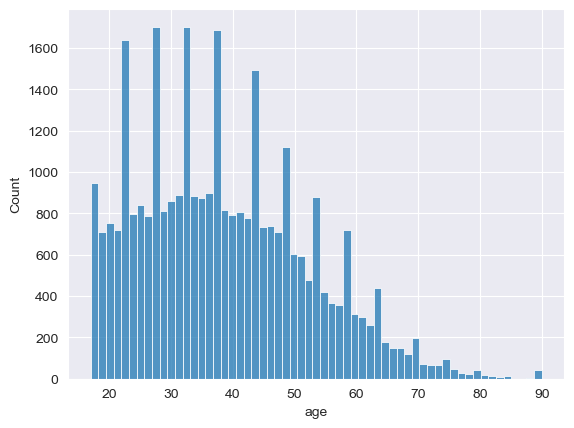

In [73]:
sns.histplot(adults['age'])
plt.show()

The histogram clearly shows a right-skewed distribution. This is logical, as most workers are between 18 and 65 years old. People in their thirties make up the age group with the highest number of workers. What is interesting about this chart is that there are a number of 90-year-old workers, but no 88- or 89-year-olds.

I also find it interesting to see if there are outliers in the age and hours.per.week columns. For this, I will create a scatterplot:

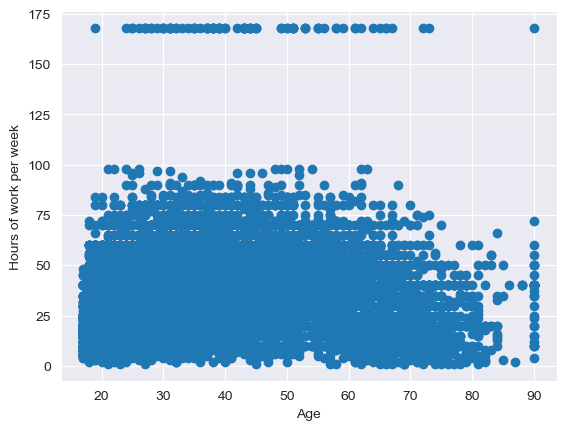

In [74]:
plt.scatter(adults['age'], adults['hours.per.week'])
plt.xlabel('Age')
plt.ylabel('Hours of work per week')
plt.show()

As you can see, hours.per.week is clearly capped around 100 hours per week, and then you suddenly have a whole bunch of outliers at 168 hours per week. These outliers must definitely be removed before training a model. In addition, there also appear to be some outliers at 90 years old. Of course, it is possible that some 90-year-olds work, but it is odd that there are otherwise very few workers between 85 and 89 years old. Therefore, I think it is best to filter out all ages above 85 as well.

A violin plot is a great way to visualize data distribution. Below is a violin plot showing age density and distribution per income group:

C:\Users\misha\AppData\Local\Temp\ipykernel_28100\1358197325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=adults, x='income', y='age', palette='Pastel1', inner="quart")


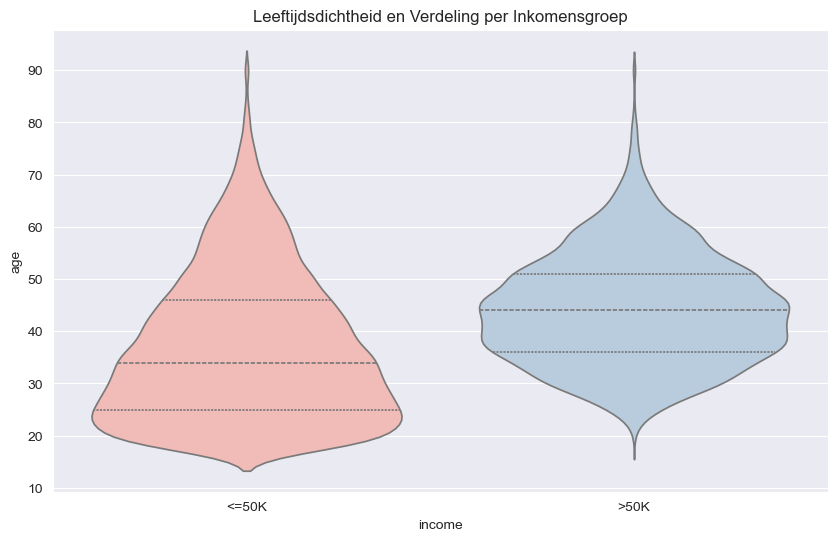

In [75]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=adults, x='income', y='age', palette='Pastel1', inner="quart")
plt.title('Leeftijdsdichtheid en Verdeling per Inkomensgroep')
plt.show()

In this chart, it is clearly visible that younger people often earn less than older people. You can see this in the "belly" of the <=50K violin, which sits lower than that of the >50K violin.

Below, I am plotting a stacked bar chart of the income percentage per education level:

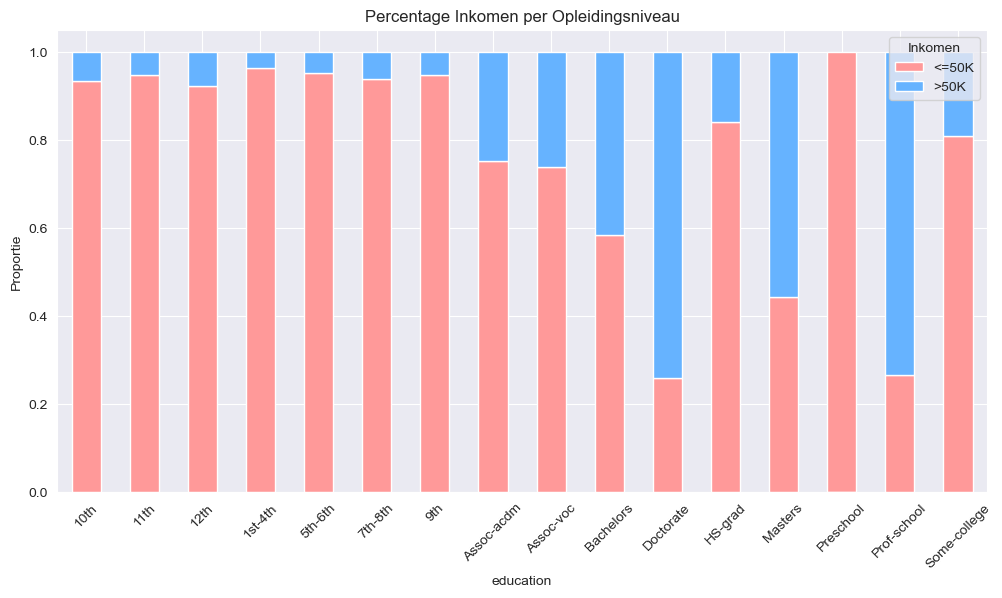

In [76]:
edu_income = adults.groupby(['education', 'income']).size().unstack()
edu_income_pct = edu_income.div(edu_income.sum(axis=1), axis=0)

edu_income_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999','#66b3ff'])
plt.title('Percentage Inkomen per Opleidingsniveau')
plt.ylabel('Proportie')
plt.legend(title='Inkomen', loc='upper right')
plt.xticks(rotation=45)
plt.show()

This chart is interesting, as we clearly see that Doctorates, Masters, and Prof-School have the highest percentage of incomes above $50,000, whereas primary school/middle school/high school (1st-12th) clearly have a lower percentage of high earners, and preschool has no high earners at all (which makes sense). Furthermore, Bachelors and Some-college fall in between, which is also logical.

Finally, I want to look at the outlier of $99,999 in the capital.gain column. I will do this using a boxplot:

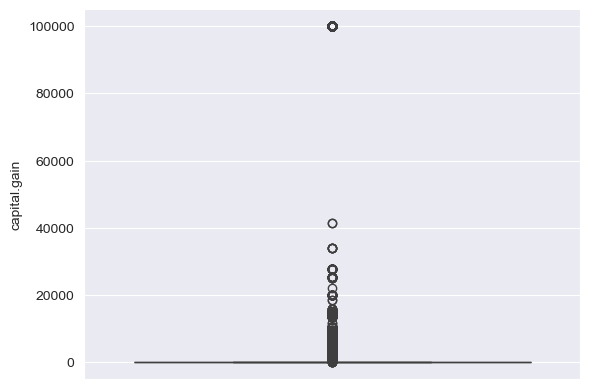

In [77]:
sns.boxplot(adults['capital.gain'])
plt.show()

It appears there are a huge number of outliers in this column—so many that the boxplot is barely visible. It scales up to just above 40,000, and then you suddenly have a mass of outliers at $99,999. These are likely people who earned more than $99,999 from their investments (much like how an hours.per.week value of 99 likely means people work 99 hours or more per week). For the model's accuracy, it is important to keep these outliers.

## Data Preparation

First, let's tackle the outliers. For now, I only want to remove outliers in age (>85) and hours.per.week (>99) as these seem unrealistic. I want to keep the $99,999 outliers because they are crucial for a model predicting whether an individual earns more than $50,000 per year.

In [78]:
current_max = adults['education.num'].max()

if pd.notnull(current_max) and current_max != 16 and current_max > 0:
    scaling_factor = current_max / 16
    adults['education.num'] = adults['education.num'] / scaling_factor

adults['education.num'] = adults['education.num'].round().astype('Int64')

edu_map = adults.dropna(subset=['education']).set_index('education.num')['education'].to_dict()
adults['education'] = adults['education'].fillna(adults['education.num'].map(edu_map))

adults['age'] = adults['age'].clip(upper=85).astype('Int64')

adults = adults[adults['hours.per.week'] <= 99].copy()
adults['hours.per.week'] = adults['hours.per.week'].astype('Int64')

adults['is_capital_maxed'] = (adults['capital.gain'] >= 99990).astype('Int64')
adults['capital_gain_log'] = np.log1p(adults['capital.gain'])

adults = adults.dropna(subset=['education.num'])

print(f"Max Age: {adults['age'].max()}")
print(f"Max Hours: {adults['hours.per.week'].max()}")
print(f"Education Range: {adults['education.num'].min()} to {adults['education.num'].max()}")
print(f"Missing Education Numbers: {adults['education.num'].isnull().sum()}")
print(f"Final Row Count: {len(adults)}")

Max Age: 85
Max Hours: 98
Education Range: 1 to 16
Missing Education Numbers: 0
Final Row Count: 32474


I have now corrected the education.num column and removed the outliers for age and hours.per.week. Additionally, I engineered two features that will come in handy when training the model: `is_capital_maxed` and `capital_gain_log`. `Is_capital_maxed` is a flag indicating whether a person is at or above the 99,999 limit. `Capital_gain_log` brings the data closer together because the original column is extremely skewed (most people have a capital.gain of 0 while some have massive amounts). This will help the model recognize patterns better.

As seen in the Data Understanding section, there were a few missing values in the dataset. Since the amount of missing data is negligible compared to the total size of the dataset (32,561 entries), I decided to simply drop all rows containing NaNs. Because most of the data consists of categorical variables, imputing them with the mode would only introduce additional noise. Furthermore, dropping these NaNs has virtually no impact on subsequent model training due to the low volume of missing values.

In [79]:
adults_clean = adults.dropna()
adults_clean.isnull().sum()

age                 0
workclass           0
fnlwgt              0
education           0
education.num       0
marital.status      0
occupation          0
relationship        0
race                0
sex                 0
capital.gain        0
capital.loss        0
hours.per.week      0
native.country      0
income              0
is_capital_maxed    0
capital_gain_log    0
dtype: int64

It looks like those NaNs are now gone.

I also want to replace the "?" values with "Unknown". It would be a shame to discard these rows, because a large portion of people with "?" values are unemployed or have never worked, which is an important feature to include when predicting whether someone earns more or less than 50K.

In [80]:
adults_clean = adults_clean.replace('?', 'Unknown')

cols_to_check = ['workclass', 'occupation', 'native.country']
for col in cols_to_check:
    unknown_count = (adults_clean[col] == 'Unknown').sum()
    print(f"{col}: {unknown_count} 'Unknown' values")

workclass: 1825 'Unknown' values
occupation: 1832 'Unknown' values
native.country: 580 'Unknown' values


## Modeling

Now that the data is cleaned, we can start the modeling phase. The research questions are as follows:
1. "How good of a model can we build to predict people's income in an ethical manner?"
2. "How much difference in model quality is there when ethically sensitive features are included?"

The target variable is, of course, `income` (<=50K or >50K). The features we will include are: age, workclass, education.num, occupation, capital.gain, capital.loss, hours.per.week, and my engineered features `capital_gain_log` and `is_capital_maxed`. These features are important because they are clear indicators of an individual's income level, as we saw with age and education in the Data Understanding phase. The rest can be shown in a correlation matrix. Then you have features like race, native.country, and sex which might be correlated with income but potentially excluded for ethical reasons. Later, I can check feature importances to see whether these features actually matter for the model. For instance, if gender is an important feature and significantly improves model performance, it might be worth including. I will train a Decision Tree Classifier, Random Forest Classifier, and kNN on the data, as this is a clear classification task (earning more than 50K or not). Regarding hyperparameters, I will definitely look at `n_estimators`, `max_depth`, and `max_features` for the Random Forest using cross-validation with GridSearchCV. Afterward, I will examine the confusion matrix, precision, and recall.

I will start by building a non-ethical model (including race, sex, and native.country). The reason for this is to inspect feature importances later and determine whether these non-ethical features are important to the model.

### Non-Ethical Model

To begin, let's first select the features we will use for our initial (non-ethical) model:

In [81]:
# Features die we meenemen, inclusief sex en race
features = [
    'age', 'workclass', 'education.num', 'occupation',
    'capital.gain', 'capital.loss', 'hours.per.week',
    'capital_gain_log', 'is_capital_maxed', 'sex', 'race'
]

X = adults_clean[features].copy()
y = adults_clean['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Dummies van categoriale features
X_final = pd.get_dummies(X, columns=['workclass', 'occupation', 'sex', 'race'], drop_first=True, dtype=int)

We will split into train and test sets:

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

Temporary dataframe to plot a correlation matrix (where we can see which of our features correlate with the target variable). We do this because if we tried to create a correlation matrix of all features, it would become far too large. This is because a large number of features are categorical, and once converted to dummies, the total quickly exceeds 100 features.

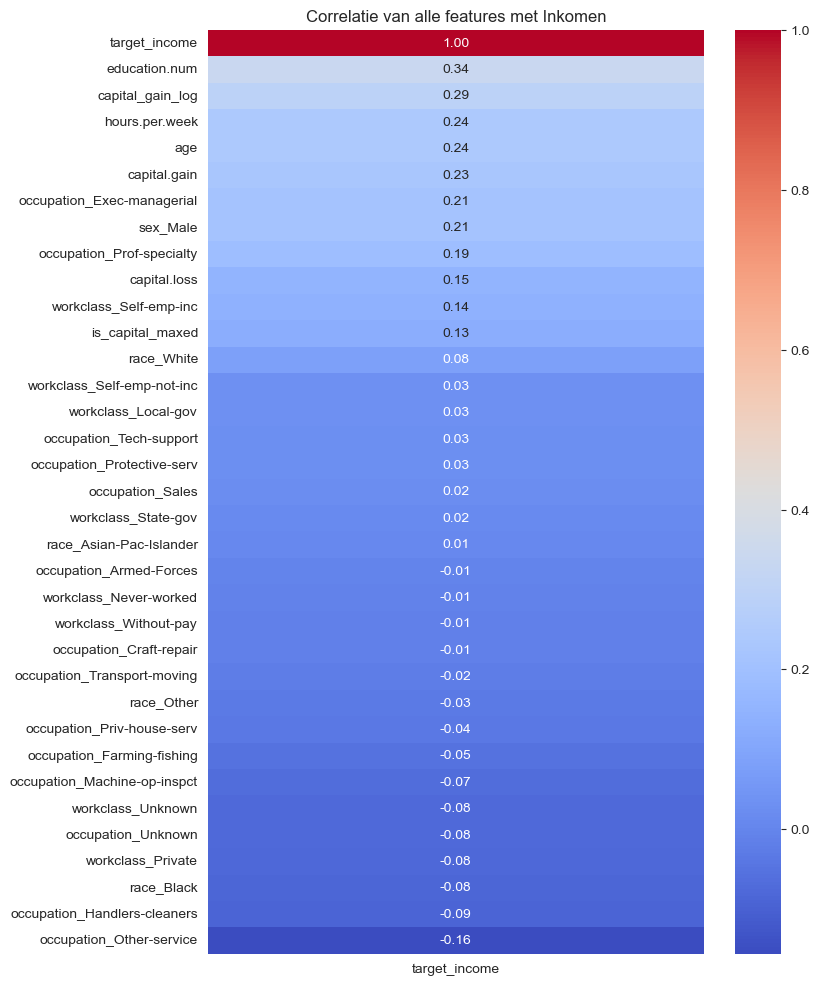

In [83]:
temp_df = X_train.copy()
temp_df['target_income'] = y_train

# Correlaties vinden
target_corr = temp_df.corr()[['target_income']].sort_values(by='target_income', ascending=False)

# Correlaties plotten
plt.figure(figsize=(8, 12))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlatie van alle features met Inkomen")
plt.show()

At first glance, these correlations may not seem huge, but for this dataset, the correlations for education.num, capital_gain_log, hours.per.week, age, and capital.gain are quite decent. For the kNN model, we need to scale the data so that the features do not span vastly different ranges.

In [84]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

A dictionary of models so we can easily train them:

In [85]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

We will perform cross-validation on each model to see which one performs best. Cross-validation involves training and testing the model multiple times on different splits of the data to ensure it is not merely memorizing the training data.

In [86]:
results = {}

# Ieder model testen
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = cv_scores.mean()
    print(f"{name:15}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

best_model_name = max(results, key=results.get)
print(f"Het best presterende basismodel is: {best_model_name}")

Decision Tree  : 0.7990 (+/- 0.0045)
Random Forest  : 0.8265 (+/- 0.0064)
KNN            : 0.8154 (+/- 0.0043)
Het best presterende basismodel is: Random Forest


Now that we know Random Forest is the best model, we will tune it to find the optimal hyperparameters. Let's start by creating the grid:

In [87]:
param_grid = {
    'n_estimators': [100, 200],          
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

Now we run GridSearchCV on this grid:

In [88]:
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


The best hyperparameters for the RF are:

In [89]:
best_rf = grid_search.best_estimator_
print(f"Beste parameters: {grid_search.best_params_}")

Beste parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}


Now we will make predictions on the test data so we can plot a Classification Report and Confusion Matrix:

In [90]:
y_pred = best_rf.predict(X_test_scaled)

Classification Report:

In [91]:
print("\nClassification Report:")
print("-" * 30)
print(classification_report(y_test, y_pred))


Classification Report:
------------------------------
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4914
           1       0.78      0.51      0.62      1566

    accuracy                           0.85      6480
   macro avg       0.82      0.73      0.76      6480
weighted avg       0.84      0.85      0.84      6480



The model achieves an overall accuracy of 85%. While this seems like a strong score, we must critically evaluate performance per class due to the imbalanced dataset (significantly more <=50K than >50K entries).

For the >50K class (high earners), we observe the following:
* **Precision (0.78):** When the model predicts that someone earns >50K, it is correct 78% of the time. The model is reasonably reliable in its positive predictions.
* **Recall (0.51):** The model only successfully identifies 51% of all actual high earners in the test set. Nearly half are incorrectly classified as <=50K.

Consequently, the model is currently very conservative when predicting >50K, causing it to miss a large portion of the target group.

Confusion Matrix:


Confusion Matrix:


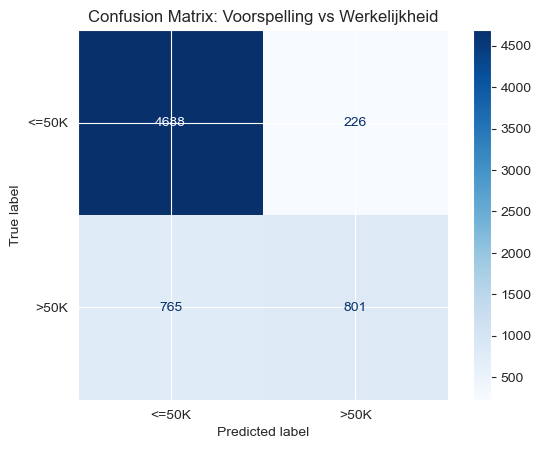

In [92]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Voorspelling vs Werkelijkheid")
plt.show()

In the confusion matrix, we can see the model's errors in absolute numbers:
* The model is extremely good at correctly classifying the majority class (<=50K), with 4,688 correct predictions in the top-left quadrant.
* The issue with the low recall is directly visible in the bottom-left quadrant: 765 people who actually earn >50K are incorrectly classified by the model as <=50K. These represent 'missed' high earners.
* The number of 'false alarms' (individuals incorrectly classified as >50K) is relatively low at 226, which explains the strong precision score.

Finally, it is interesting to examine the feature importances, as this allows us to see what effect the non-ethical features had on the model.

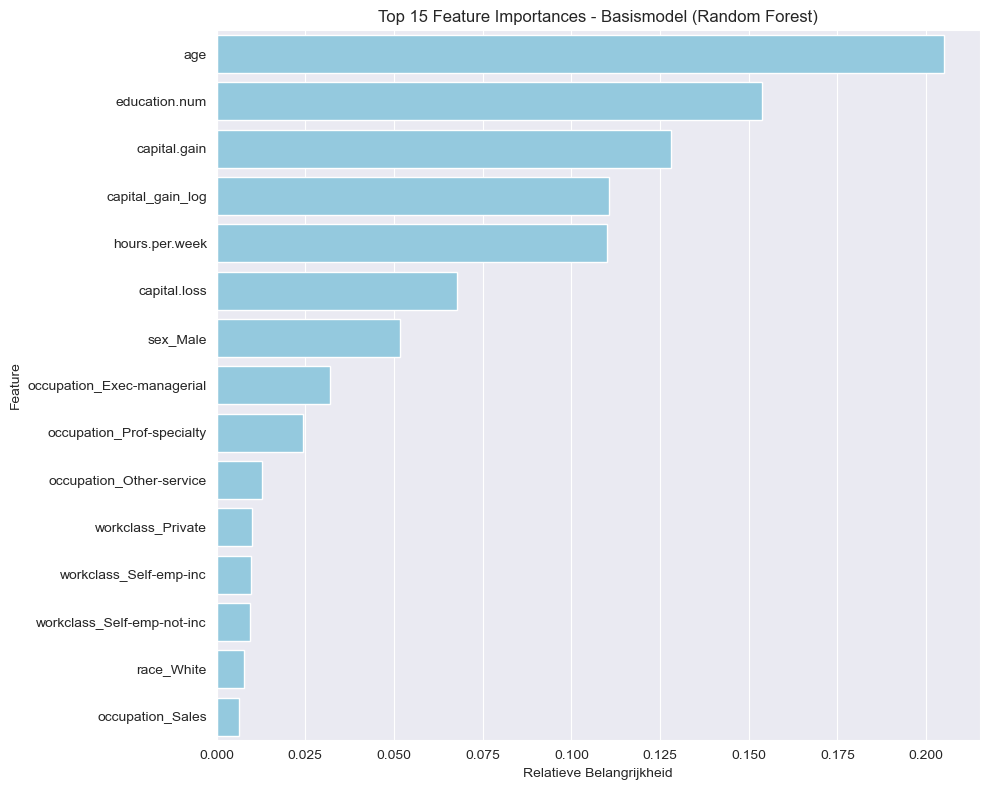

Top 10 belangrijkste features:
                   Feature  Importance
                       age    0.204914
             education.num    0.153676
              capital.gain    0.128013
          capital_gain_log    0.110653
            hours.per.week    0.110039
              capital.loss    0.067738
                  sex_Male    0.051774
occupation_Exec-managerial    0.031838
 occupation_Prof-specialty    0.024247
  occupation_Other-service    0.012849
         workclass_Private    0.009873
    workclass_Self-emp-inc    0.009777
workclass_Self-emp-not-inc    0.009485
                race_White    0.007772
          occupation_Sales    0.006317


In [93]:
importances = best_rf.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), color='skyblue')
plt.title('Top 15 Feature Importances - Basismodel (Random Forest)')
plt.xlabel('Relatieve Belangrijkheid')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 10 belangrijkste features:")
print(feature_importance_df.head(15).to_string(index=False))

From the chart and the top 10, we can infer the following:
* **Objective factors carry the most weight:** `age`, `education.num`, `capital.gain` / `capital_gain_log`, and `hours.per.week` account for the vast majority of the prediction weight. This aligns with expectations.
* **Ethical pain points are clearly present:** In 7th place, we find the variable `sex_Male` with an importance score of ~0.05. Further down in the top 15, we also see `race_White` appearing.

The model is quantitatively quite strong, but it is not ethically responsible. It actively uses sensitive personal characteristics such as gender and race to determine whether someone is likely to have a high or low income.

This first Random Forest model predicts the correct income in 85% of cases. It performs very well at recognizing incomes under 50K, but struggles somewhat more with high earners: it misses nearly half of the individuals who actually earn more than 50K.

To properly answer the research question, we will now train a new model without ethically sensitive features, such as `sex` and `race`. This will allow us to directly compare how much prediction quality changes when we work in a more ethically responsible manner!

### Ethical Model

From the feature importances of our non-ethical model, it became clear that ethically sensitive attributes—specifically gender (`sex_Male`) and race (`race_White`)—played a significant role in predicting an individual's income.

To investigate whether we can predict people's income in an ethically responsible manner, we will now train the exact same Random Forest model, but on a dataset from which `sex` and `race` have been completely removed. Afterward, we will compare its performance with our non-ethical model to answer our second research question.

Selecting features, splitting, and scaling:

In [94]:
# Definieer de features
ethical_features = [
    'age', 'workclass', 'education.num', 'occupation',
    'capital.gain', 'capital.loss', 'hours.per.week',
    'capital_gain_log', 'is_capital_maxed'
]

# Selecteer de data
X_ethical = adults_clean[ethical_features].copy()
y_ethical = adults_clean['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Maak dummies aan voor de categorische variabelen
X_ethical_final = pd.get_dummies(X_ethical, columns=['workclass', 'occupation'], drop_first=True, dtype=int)

# Splitsen in train en test
X_train_eth, X_test_eth, y_train_eth, y_test_eth = train_test_split(
    X_ethical_final, y_ethical, test_size=0.2, random_state=42
)

# Schalen van de data
scaler_eth = StandardScaler()
X_train_eth_scaled = scaler_eth.fit_transform(X_train_eth)
X_test_eth_scaled = scaler_eth.transform(X_test_eth)

Crucial for comparing the two models is ensuring that the exact same parameters are passed to the ethical model as those found for the non-ethical model. Let's train the model and make predictions:

In [95]:
# Definieer het Random Forest model met de eerder gevonden optimale hyperparameters
ethical_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42
)

# Train het ethische model
ethical_rf.fit(X_train_eth_scaled, y_train_eth)

# Maak voorspellingen
y_pred_eth = ethical_rf.predict(X_test_eth_scaled)

And finally, a classification report and confusion matrix:

Classification Report - ETHISCH MODEL:
------------------------------
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      4914
           1       0.76      0.48      0.59      1566

    accuracy                           0.84      6480
   macro avg       0.80      0.72      0.74      6480
weighted avg       0.83      0.84      0.82      6480

\nConfusion Matrix - ETHISCH MODEL:


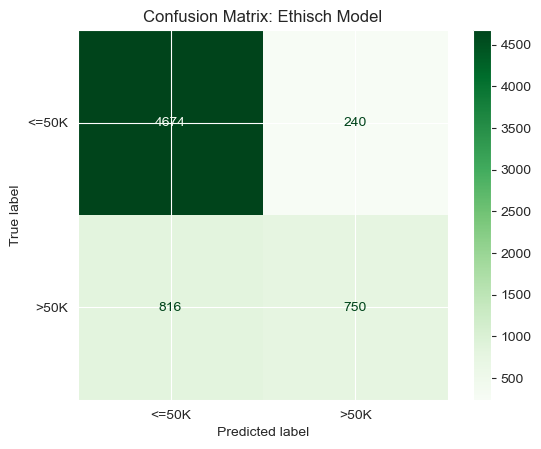

In [96]:
print("Classification Report - ETHISCH MODEL:")
print("-" * 30)
print(classification_report(y_test_eth, y_pred_eth))

print("\\nConfusion Matrix - ETHISCH MODEL:")
cm_eth = confusion_matrix(y_test_eth, y_pred_eth)
disp_eth = ConfusionMatrixDisplay(confusion_matrix=cm_eth, display_labels=['<=50K', '>50K'])
disp_eth.plot(cmap='Greens')
plt.title("Confusion Matrix: Ethisch Model")
plt.show()

### Conclusion: Modeling

This part of the case study focused on two key research questions:
1. How good of a model can we build to predict people's income in an ethical manner?
2. How much difference in model quality is there when ethically questionable features are included?

To answer these questions, we compared the results of the non-ethical model (including gender and race) with the ethical model (from which these attributes were removed).

When comparing the metrics of both Random Forest models side by side, we observe the following:
* **Accuracy:** Drops by only 1 percentage point (from 85% to 84%).
* **Precision (>50K):** Drops marginally from 0.78 to 0.76.
* **Recall (>50K):** Decreases slightly, from 0.51 to 0.48. The ethical model misses 51 additional high earners (False Negatives increase from 765 to 816), but overall proportions remain largely intact.

The feature importances of the non-ethical model revealed that the algorithm actively used attributes such as gender (`sex_Male`) and race (`race_White`) to predict income. Ethically speaking, this is highly undesirable.

By removing these features, we forced the model to rely solely on objective factors such as education, age, working hours, and capital. The results of the ethical model show that prediction quality barely declines as a result. A 1% drop in accuracy and a 3% drop in recall is a very small price to pay for a model free from direct discrimination based on gender and race.

**Conclusion:** It is entirely feasible to use machine learning to predict individuals' income reliably and in an ethically responsible manner. Incorporating ethically sensitive features yields negligible performance gains and is vastly outweighed by the moral and societal objections.